In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import colormaps as cm

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FuncAnimation, FFMpegWriter

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# meta
_scratch = "/pscratch/sd/n/nagarwal"
_prototype = "ocn-only"
_expt = "R5"
_subexpt = "T1M"
_fcast_nhours = "240h" 

In [25]:
_expt_dir = os.path.join(_scratch, _prototype, _expt)
if _subexpt:
    inference_dir = os.path.join(_expt_dir, f"inference_{_subexpt}", "validation")
else:
    inference_dir = os.path.join(_expt_dir, f"inference_{_subexpt}", "validation")

predictions = xr.open_zarr(f"{inference_dir}/graphufs.{_fcast_nhours}.zarr")
targets = xr.open_zarr(f"{inference_dir}/replay.{_fcast_nhours}.zarr")

In [5]:
predictions

<xarray.Dataset> Size: 44GB
Dimensions:    (time: 512, lead_time: 10, lat: 192, lon: 384, z_l: 7)
Coordinates:
  * lat        (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lead_time  (lead_time) timedelta64[ns] 80B 1 days 2 days ... 9 days 10 days
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time       (time) datetime64[ns] 4kB 2022-01-01 ... 2023-10-01T18:00:00
  * z_l        (z_l) float64 56B 0.5154 11.06 47.21 93.67 152.1 271.2 417.7
Data variables:
    SSH        (time, lead_time, lat, lon) float32 2GB dask.array<chunksize=(1, 10, 192, 384), meta=np.ndarray>
    so         (time, lead_time, z_l, lat, lon) float32 11GB dask.array<chunksize=(1, 10, 7, 192, 384), meta=np.ndarray>
    temp       (time, lead_time, z_l, lat, lon) float32 11GB dask.array<chunksize=(1, 10, 7, 192, 384), meta=np.ndarray>
    uo         (time, lead_time, z_l, lat, lon) float32 11GB dask.array<chunksize=(1, 10, 7, 192, 384), meta=np.ndarray>
    vo         (time, lead_time, z_l, lat, lon) float32 11GB dask.array<chunksize=(1, 10, 7, 192, 384), meta=np.ndarray>

## REPLAY ocean

In [23]:
# Open the existing ocean zarr-store
ocn = xr.open_zarr(
    "gs://noaa-ufs-gefsv13replay/ufs-hr1/0.25-degree-subsampled/06h-freq/zarr/mom6.zarr",
    storage_options={"token": "anon"},
)
ocn

<xarray.Dataset> Size: 5TB
Dimensions:       (time: 43826, lat: 192, lon: 384, zl: 75, z_l: 75)
Coordinates:
    cftime        (time) object 351kB dask.array<chunksize=(21913,), meta=np.ndarray>
    ftime         (time) timedelta64[ns] 351kB dask.array<chunksize=(21913,), meta=np.ndarray>
  * lat           (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lon           (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time          (time) datetime64[ns] 351kB 1993-12-31T18:00:00 ... 2023-12-31
  * z_l           (z_l) float64 600B 0.5154 1.571 2.687 ... 5.698e+03 5.902e+03
  * zl            (zl) float64 600B 1.0 3.0 5.0 ... 3.591e+03 5.111e+03
Data variables: (12/21)
    Heat_PmE      (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    LW            (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    LwLatSens     (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    SSH           (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    SW            (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    depth         (lat, lon) float32 295kB dask.array<chunksize=(96, 384), meta=np.ndarray>
    ...            ...
    so            (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
    taux          (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    tauy          (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    temp          (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
    uo            (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
    vo            (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>

### Plot 10-day lead forecast for SSH, SST, surface U/V in a single row.

In [27]:
def plot_panel(ax, field, lat2d, lon2d, mask, vmin=0, vmax=1,
               cmap="viridis", central_lat=0.0, central_lon=0.0, 
               nclevels=100, title=""):
    
    ax.set_title(title, fontsize=12)
    proj_ax = ccrs.Orthographic(central_longitude=central_lon, central_latitude=central_lat)
    ax.projection = proj_ax
    ax.set_global()
    ax.coastlines()
    #ax_left.add_feature(cfeature.BORDERS, linewidth=0.5)
    cf = ax.contourf(lon2d, lat2d, field.where(mask), nclevels, transform=ccrs.PlateCarree(), 
                     cmap=cmap, vmin=vmin, vmax=vmax, extend='both')
    ax.add_feature(cfeature.LAND, facecolor='black',)
    ax.add_feature(cfeature.RIVERS, linewidth=0.3,)
    
    return ax

In [31]:
itime = 0 
ileadtime = 9 # equal to 10 days using 24h emulator
leadtime_int = int(predictions.lead_time[ileadtime].values/3600/1e9)

# plotting related
central_lat = 10
central_lon = -60

lons = predictions["lon"]
lats = predictions["lat"]
times = predictions["lead_time"]
lon2d, lat2d = np.meshgrid(lons, lats)

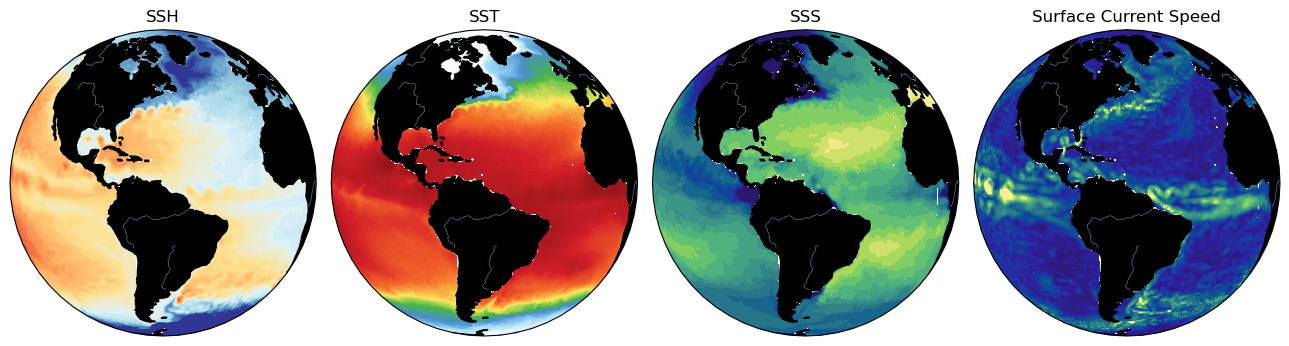

In [45]:
fig, axs = plt.subplots(1, 4, figsize=(13, 5),
                        subplot_kw={'projection': ccrs.Orthographic(central_longitude=central_lon, central_latitude=central_lat)})

kwargs = {"cbar_kwargs":{"orientation": "horizontal", "shrink":0.7, "pad":0.05}, "robust":True,}

# SSH
ax = axs[0]
variable = "SSH"
vmin=-1; vmax=1; cmap=cm.cmp_b2r
field = predictions[variable].isel(time=itime, lead_time=ileadtime).squeeze()
mask = 1 - np.isnan(ocn.SSH.isel(time=0))
ax = plot_panel(ax, field, lat2d, lon2d, mask, vmin=vmin, vmax=vmax, cmap=cmap, 
                central_lat=central_lat, central_lon=central_lon, title="SSH")

# SST
ax = axs[1]
variable = "temp"; iz_l=0
vmin=-2; vmax=30; cmap=cm.WhiteBlueGreenYellowRed
field = predictions[variable].isel(z_l=iz_l, time=itime, lead_time=ileadtime).squeeze()
mask = xr.where(targets.so.isel(time=itime, lead_time=0, z_l=iz_l,)==0, 0, 1)
ax = plot_panel(ax, field, lat2d, lon2d, mask, vmin=vmin, vmax=vmax, cmap=cmap, 
                central_lat=central_lat, central_lon=central_lon, title="SST")

# SSS
ax = axs[2]
variable = "so"; iz_l=0
vmin=32; vmax=38; cmap=cm.haline
field = predictions[variable].isel(z_l=iz_l, time=itime, lead_time=ileadtime).squeeze()
ax = plot_panel(ax, field, lat2d, lon2d, mask, vmin=vmin, vmax=vmax, cmap=cmap, 
                central_lat=central_lat, central_lon=central_lon, title="SSS")

# Surface current speed
ax = axs[3]
iz_l=0

variable = "uo"
field_u = predictions[variable].isel(z_l=iz_l, time=itime, lead_time=ileadtime).squeeze()

variable = "vo"
field_v = predictions[variable].isel(z_l=iz_l, time=itime, lead_time=ileadtime).squeeze()
field = np.sqrt(field_u**2 + field_v**2)
vmin=0; vmax=1; cmap=cm.haline
ax = plot_panel(ax, field, lat2d, lon2d, mask, vmin=vmin, vmax=vmax, cmap=cmap, 
                central_lat=central_lat, central_lon=central_lon, title="Surface Current Speed")

leadtime = pd.to_timedelta(predictions.coords["lead_time"][ileadtime].values, unit="D")
initdate = predictions.coords["time"][itime].values
#plt.suptitle(f"{_descrip}: {variable}, z_l={target.z_l.values:.2f}m, lead_time={leadtime}, init_datetime={initdate}")
plt.tight_layout()
#plt.savefig(os.path.join(_figdir, f"{variable}_fcast_z_l={target.z_l.values:.2f}m_{leadtime_int}h_{_descrip}_{_expt}_{_sub_expt}.png"), dpi=300)

plt.show()